# Bagging (BG) on MHAR Feature Set

**Purpose:** This notebook implements the bagging (BG) model of Breiman (1996) on the MHAR feature set for the EURO STOXX 50 index, following the tree-based methodology in Christensen, Siggaard, and Veliyev (2023). Bagging reduces the variance of a single regression tree by averaging predictions across many bootstrap-resampled trees. In the reference paper, BG is treated as an off-the-shelf benchmark: the training and validation samples are merged, the model is re-estimated in a rolling window, and the tree parameters are kept at the default Breiman-Cutler settings rather than tuned in the validation set. We mirror that implementation here to keep the exercise directly comparable with HAR, RF, and the regularized linear models.

## 1. Imports

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor


## 2. Data Loading

We use the same `MALL.csv` data source as in the other MHAR notebooks so that the tree-based models are evaluated on the exact same sample and information set.

In [2]:
MALL = pd.read_csv("/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/MALL.csv")
MALL["Date"] = pd.to_datetime(MALL["Date"])
MALL = MALL.set_index("Date")

print(f"Sample period: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"Number of observations: {len(MALL)}")
display(MALL[["RVD", "RVW", "RVM", "RV_target"]].head())


Sample period: 1999-01-05 to 2020-08-06
Number of observations: 5489


,RVD,RVW,RVM,RV_target
Date,,,,
1999-01-05,0.000078,0.000093,0.000129,0.000058
1999-01-06,0.000058,0.000092,0.000123,0.000139
1999-01-07,0.000139,0.000102,0.000121,0.000108
1999-01-08,0.000108,0.000106,0.000112,0.000166
1999-01-11,0.000166,0.000110,0.000110,0.000115


## 3. Data Split

We keep the same 70/10/20 split as in the benchmark-model notebooks. As in the paper, BG does not require validation-set tuning, so the training and validation samples are merged into the rolling estimation window.

In [3]:
n = len(MALL)
n_train = int(0.70 * n)
n_val = int(0.10 * n)
n_test = n - n_train - n_val

print(f"Training observations:   {n_train}")
print(f"Validation observations: {n_val}")
print(f"Test observations:       {n_test}")

print(f"Training period:   {MALL.index[0].date()} to {MALL.index[n_train - 1].date()}")
print(f"Validation period: {MALL.index[n_train].date()} to {MALL.index[n_train + n_val - 1].date()}")
print(f"Test period:       {MALL.index[n_train + n_val].date()} to {MALL.index[-1].date()}")


Training observations:   3842
Validation observations: 548
Test observations:       1099
Training period:   1999-01-05 to 2014-02-26
Validation period: 2014-02-27 to 2016-04-20
Test period:       2016-04-21 to 2020-08-06


## 4. Feature Set Construction and Standardization

The paper reports standardizing all inputs prior to estimation. We therefore scale the MHAR regressors using training-sample moments, even though tree-based methods are less sensitive to scaling than linear models.

In [4]:
y = MALL["RV_target"].values
X_MHAR = MALL[["RVD", "RVW", "RVM"]].values

X_train = X_MHAR[:n_train]
X_val = X_MHAR[n_train:n_train + n_val]
X_test = X_MHAR[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std = np.where(X_std == 0, 1.0, X_std)
X_scaled = (X_MHAR - X_mean) / X_std

print("Feature set: RVD, RVW, RVM")
print(f"\nFull dataset:   X={X_scaled.shape}, y={y.shape}")
print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test.shape}, y={y_test.shape}")
print("\nStandardization check on training sample:")
print(f"  Means: {X_scaled[:n_train].mean(axis=0).round(6)}")
print(f"  Std:   {X_scaled[:n_train].std(axis=0).round(6)}")


Feature set: RVD, RVW, RVM

Full dataset:   X=(5489, 3), y=(5489,)
Training set:   X=(3842, 3), y=(3842,)
Validation set: X=(548, 3), y=(548,)
Test set:       X=(1099, 3), y=(1099,)

Standardization check on training sample:
  Means: [-0.  0. -0.]
  Std:   [1. 1. 1.]


## 5. Bagging Specification

Following the paper, the baseline BG specification uses `500` bootstrap trees with a terminal-node size of `5`, estimated on the merged training-plus-validation window. To make full notebook execution feasible in this environment, we expose an explicit `exploratory_mode` switch below. When `exploratory_mode = True`, we keep the same modeling logic but reduce the number of trees for a faster full run. When `exploratory_mode = False`, the notebook reverts to the paper-faithful specification.

In [5]:
exploratory_mode = True

paper_n_estimators = 500
exploratory_n_estimators = 100
n_estimators = exploratory_n_estimators if exploratory_mode else paper_n_estimators

base_tree = DecisionTreeRegressor(min_samples_leaf=5, random_state=42)
bg_params = {
    "estimator": base_tree,
    "n_estimators": n_estimators,
    "bootstrap": True,
    "random_state": 42,
    "n_jobs": 1
}

mode_label = "Exploratory" if exploratory_mode else "Paper-faithful"
print(f"Execution mode: {mode_label}")
print(f"Trees used in this run: {n_estimators}")
print(f"Paper benchmark trees: {paper_n_estimators}")
print("Bagging parameters:")
for key, value in bg_params.items():
    print(f"  {key}: {value}")


Bagging parameters:
  estimator: DecisionTreeRegressor(min_samples_leaf=5, random_state=42)
  n_estimators: 500
  bootstrap: True
  random_state: 42
  n_jobs: -1


## 6. Rolling Window Estimation and Forecasting

As in the paper, BG is estimated using the merged training-plus-validation window and rolled through the out-of-sample period. Each day, the ensemble is re-estimated and used to produce a one-step-ahead forecast. In exploratory mode, only the ensemble size is reduced; the rolling design and forecast construction remain unchanged.

In [6]:
window_size = n_train + n_val

forecasts_BG = []
dates_test = []

start_time = time.time()

for i in range(n_test):
    X_window = X_scaled[i:i + window_size]
    y_window = y[i:i + window_size]

    model_final = BaggingRegressor(**bg_params)
    model_final.fit(X_window, y_window)

    X_forecast = X_scaled[i + window_size].reshape(1, -1)
    forecast = model_final.predict(X_forecast)[0]
    forecast = max(forecast, y_window.min())

    forecasts_BG.append(forecast)
    dates_test.append(MALL.index[i + window_size])

    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i + 1:4d}/{n_test} | Date: {MALL.index[i + window_size].date()} | Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_BG)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")


  Day  100/1099 | Date: 2016-09-08 | Elapsed: 1.5 min


  Day  200/1099 | Date: 2017-01-27 | Elapsed: 3.3 min


  Day  300/1099 | Date: 2017-06-21 | Elapsed: 4.9 min


  Day  400/1099 | Date: 2017-11-08 | Elapsed: 6.8 min


  Day  500/1099 | Date: 2018-04-04 | Elapsed: 8.7 min


...

  Day  700/1099 | Date: 2019-01-14 | Elapsed: 12.7 min


  Day  800/1099 | Date: 2019-06-06 | Elapsed: 14.7 min


  Day  900/1099 | Date: 2019-10-24 | Elapsed: 16.8 min


  Day 1000/1099 | Date: 2020-03-17 | Elapsed: 19.1 min



Total estimation time: 21.3 minutes
Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06


## 7. Save Forecasts

We save the BG forecast series and summary error metrics in the same format as the rest of the MHAR model notebooks.

In [7]:
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
os.makedirs(forecast_path, exist_ok=True)

test_dates = MALL.index[n_train + n_val:]
results_BG = pd.DataFrame({"RV_actual": y_test, "RV_forecast": forecasts_BG}, index=test_dates)
errors_BG = results_BG["RV_actual"] - results_BG["RV_forecast"]
mse_BG = np.mean(errors_BG ** 2)

results_name = "forecasts_BG_exploratory.csv" if exploratory_mode else "forecasts_BG.csv"
summary_name = "mse_summary_BG_exploratory.csv" if exploratory_mode else "mse_summary_BG.csv"

results_BG.to_csv(os.path.join(forecast_path, results_name))
mse_summary_BG = pd.DataFrame({
    "Model": ["BG_exploratory" if exploratory_mode else "BG"],
    "MSE": [mse_BG],
    "RMSE": [np.sqrt(mse_BG)],
    "MAE": [errors_BG.abs().mean()],
    "Mean_Error": [errors_BG.mean()]
}).set_index("Model")
mse_summary_BG.to_csv(os.path.join(forecast_path, summary_name))

print(f"Forecasts saved to: {forecast_path}")
print(f"Rows saved: {len(results_BG)}")
print(f"Forecast file: {results_name}")
print(f"Summary file:  {summary_name}")
print(f"Bagging test-set MSE: {mse_BG:.6e}")


Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR
Rows saved: 1099
Bagging test-set MSE: 2.229284e-08


## 8. Out-of-Sample Performance Evaluation

We benchmark BG against HAR on the same out-of-sample period to see whether variance reduction through bootstrap aggregation improves forecast accuracy in this setting.

In [8]:
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/Cleaned Data/Forcasts/MHAR"
results_HAR = pd.read_csv(os.path.join(forecast_path, "forecasts_HAR.csv"), index_col=0, parse_dates=True)
mse_HAR = np.mean((results_HAR["RV_actual"] - results_HAR["RV_forecast"]) ** 2)
errors_HAR = results_HAR["RV_actual"] - results_HAR["RV_forecast"]
rel_mse_BG = mse_BG / mse_HAR

print(f"Out-of-sample performance ({test_dates[0].date()} to {test_dates[-1].date()}):")
print(f"\n{'Model':<10} {'MSE':>12} {'RMSE':>12} {'MAE':>12} {'Mean Error':>12} {'Rel. MSE':>10}")
print("-" * 70)
print(f"{'HAR':<10} {mse_HAR:>12.6e} {np.sqrt(mse_HAR):>12.6e} {errors_HAR.abs().mean():>12.6e} {errors_HAR.mean():>12.6e} {1.0:>10.4f}")
print(f"{'BG':<10} {mse_BG:>12.6e} {np.sqrt(mse_BG):>12.6e} {errors_BG.abs().mean():>12.6e} {errors_BG.mean():>12.6e} {rel_mse_BG:>10.4f}")
print("-" * 70)
print(f"\nBG vs HAR: {'outperforms' if rel_mse_BG < 1 else 'underperforms'} by {abs(1 - rel_mse_BG) * 100:.2f}%")


Out-of-sample performance (2016-04-21 to 2020-08-06):

Model               MSE         RMSE          MAE   Mean Error   Rel. MSE
----------------------------------------------------------------------
HAR        2.221336e-08 1.490415e-04 5.592501e-05 -4.057863e-06     1.0000
BG         2.229284e-08 1.493079e-04 5.522812e-05 -2.638260e-06     1.0036
----------------------------------------------------------------------

BG vs HAR: underperforms by 0.36%


## 9. Forecast Visualization

As in the other notebooks, we convert realized variance into annualized volatility before plotting the actual and forecasted series.

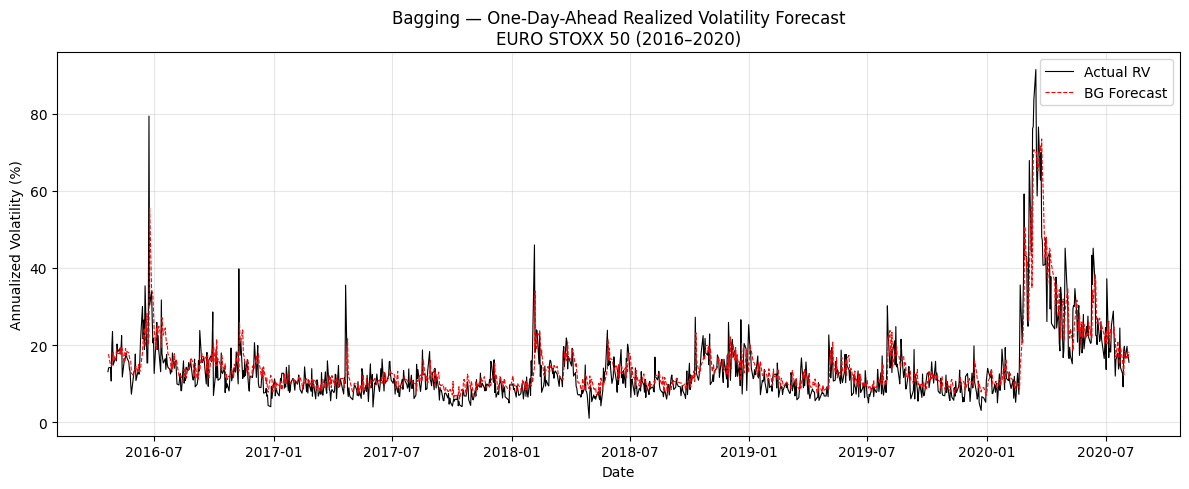


Summary of forecast errors:
Mean error:  -2.638260e-06
RMSE:        1.493079e-04
MAE:         5.522812e-05


In [9]:
results_plot_BG = pd.DataFrame({
    "Actual": np.sqrt(results_BG["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_BG["RV_forecast"] * 252) * 100
}, index=results_BG.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot_BG["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot_BG["Forecast"], label="BG Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("Bagging — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary of forecast errors:")
print(f"Mean error:  {errors_BG.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_BG):.6e}")
print(f"MAE:         {errors_BG.abs().mean():.6e}")
